# **EBPP Final Project:** One Player Contribution Analysis

In this notebook we try to estimate and compare the individual contribution of Mirotic at the end of a play, comparing it with the performance of the team when he is not in the court. Then, we will use a **Bayesian Logistic Regressor** to check if this performance changes when we are in a clutch moment, in a local or visitant game or playing againts Real Madrid, for example.

The objective is to predict the probability of finishing the play with a good shot (`good_shot`) based on the players present on the court. To start, we will analyze the case of Mirotic and compare it with the team performance when Mirotic is not on the court.

In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

## Data loading

In [3]:
df = pd.read_csv("data/Data_AllSeason.csv")

headers = ['play_id', 'point_guard', 'shooting_guard', 'small_forward', 'power_forward', 'center', 'points_difference',
           'play_type', 'good_shot', 'points', 'quarter', 'clutch', 'opponent', 'court', 'competition']
df.columns = headers

display(df)

,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition
0,1,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,0,2,1,2,1,0,Alba Berlin,Local,Eurolliga
1,2,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,2,2,1,3,1,0,Alba Berlin,Local,Eurolliga
2,3,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,2,1,0,Alba Berlin,Local,Eurolliga
3,4,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,3,1,0,Alba Berlin,Local,Eurolliga
4,5,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,8,4,1,0,1,0,Alba Berlin,Local,Eurolliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3637,3638,Calathes,Higgins,Abrines,Mirotic,Sanli,7,4,1,2,4,0,Olympiacos,Neutral,F4
3638,3639,Calathes,Higgins,Abrines,Mirotic,Sanli,6,4,0,0,4,1,Olympiacos,Neutral,F4
3639,3640,Calathes,Higgins,Abrines,Mirotic,Sanli,5,2,1,2,4,1,Olympiacos,Neutral,F4
3640,3641,Calathes,Higgins,Abrines,Mirotic,Sanli,7,1,1,2,4,0,Olympiacos,Neutral,F4


We create a DataFrame only containing the plays where Mirotic was present on the court and another one for Davies.

In [4]:
df_mirotic = df[(df['point_guard'] == 'Mirotic') |
                (df['shooting_guard'] == 'Mirotic') |
                (df['small_forward'] == 'Mirotic') |
                (df['power_forward'] == 'Mirotic') |
                (df['center'] == 'Mirotic')]

display(df_mirotic)

df_no_mirotic = df[(df['point_guard'] != 'Mirotic') &
                (df['shooting_guard'] != 'Mirotic') &
                (df['small_forward'] != 'Mirotic') &
                (df['power_forward'] != 'Mirotic') &
                (df['center'] != 'Mirotic')]

display(df_no_mirotic)

,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition
0,1,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,0,2,1,2,1,0,Alba Berlin,Local,Eurolliga
1,2,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,2,2,1,3,1,0,Alba Berlin,Local,Eurolliga
2,3,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,2,1,0,Alba Berlin,Local,Eurolliga
3,4,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,3,1,0,Alba Berlin,Local,Eurolliga
4,5,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,8,4,1,0,1,0,Alba Berlin,Local,Eurolliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3637,3638,Calathes,Higgins,Abrines,Mirotic,Sanli,7,4,1,2,4,0,Olympiacos,Neutral,F4
3638,3639,Calathes,Higgins,Abrines,Mirotic,Sanli,6,4,0,0,4,1,Olympiacos,Neutral,F4
3639,3640,Calathes,Higgins,Abrines,Mirotic,Sanli,5,2,1,2,4,1,Olympiacos,Neutral,F4
3640,3641,Calathes,Higgins,Abrines,Mirotic,Sanli,7,1,1,2,4,0,Olympiacos,Neutral,F4


,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition
19,20,Jokubaitis,Laprovittola,Kuric,Smits,Sanli,9,2,1,3,1,0,Alba Berlin,Local,Eurolliga
20,21,Jokubaitis,Laprovittola,Kuric,Smits,Sanli,12,2,0,0,1,0,Alba Berlin,Local,Eurolliga
21,22,Jokubaitis,Laprovittola,Kuric,Smits,Oriola,10,2,1,3,1,0,Alba Berlin,Local,Eurolliga
22,23,Jokubaitis,Laprovittola,Kuric,Smits,Oriola,13,5,1,0,1,0,Alba Berlin,Local,Eurolliga
23,24,Jokubaitis,Laprovittola,Kuric,Smits,Sanli,13,2,1,2,2,0,Alba Berlin,Local,Eurolliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3623,3624,Jokubaitis,Higgins,Kuric,Hayes-Davis,Sanli,8,1,0,0,4,0,Olympiacos,Neutral,F4
3624,3625,Jokubaitis,Higgins,Kuric,Hayes-Davis,Sanli,6,2,0,0,4,0,Olympiacos,Neutral,F4
3625,3626,Jokubaitis,Higgins,Kuric,Hayes-Davis,Sanli,6,3,1,0,4,0,Olympiacos,Neutral,F4
3626,3627,Jokubaitis,Higgins,Abrines,Hayes-Davis,Sanli,4,4,0,0,4,0,Olympiacos,Neutral,F4


## 1. Exploration of the `good_shot` column

In [5]:
# Case M)
case_m = df_mirotic['good_shot'] == 1

y_m = case_m.sum()
pi_hat_m = case_m.mean()

print("- Mirotic Case (good_shot = 1):")
print(f"Number of successes: {y_m} of {len(df_mirotic)}")
print(f"Sample proportion: {pi_hat_m}\n")


# Case D)
case_n = df_no_mirotic['good_shot'] == 1

y_n = case_n.sum()
pi_hat_n = case_n.mean()

print("- No Mirotic Case (good_shot = 1):")
print(f"Number of successes: {y_n} of {len(df_no_mirotic)}")
print(f"Sample proportion: {pi_hat_n}")

- Mirotic Case (good_shot = 1):
Number of successes: 1417 of 2132
Sample proportion: 0.6646341463414634

- No Mirotic Case (good_shot = 1):
Number of successes: 910 of 1510
Sample proportion: 0.6026490066225165


Now, we will check the proportion of good shots for the general dataset, so that later we can have an informed prior:

In [6]:
general_case = df['good_shot'] == 1

y_g = general_case.sum()
pi_hat_g = general_case.mean()

print("- General Case (good_shot = 1):")
print(f"Number of successes: {y_g} of {len(df)}")
print(f"Sample proportion: {pi_hat_g}\n")

- General Case (good_shot = 1):
Number of successes: 2327 of 3642
Sample proportion: 0.6389346512904998



## 2. Model choice

Observe that we only have two options (Success or Failure) for a fixed population in both cases, which clearly follows a Binomial distribution. Moreover, since our goal is to estimate a proportion and the Beta distribution is defined in the interval $[0 , 1]$, this makes the **Beta-Binomial** distribution a clear option.

Therefore, we have the following Bayesian model for each case:
- Mirotic Case:
$$
Y_M \mid \pi_M \sim \mathrm{Binomial}(2132,\pi_M),
\qquad
\pi_M \sim \mathrm{Beta}(\alpha,\beta).
$$

- No Mirotic Case:
$$
Y_N \mid \pi_N \sim \mathrm{Binomial}(1510,\pi_N),
\qquad
\pi_N \sim \mathrm{Beta}(\alpha,\beta).
$$
Where $Y_M$ and $Y_N$ are the observed number of successes, $\pi_M$ and $\pi_N$ are the unknown true population proportion, and $n_M=2132$ and $n_D=1510$ are the total sample size for the Mirotic and No Mirotic case respectively.

## 3. Prior definition

We chose an **Empirical Bayes** prior based on the team's overall success rate ($p = 0.63$) seen before. We set the prior strength to $N = 70$ (about 3-4% of our total data), which provides a stable baseline without overwhelming the actual evidence from the data. We apply the same prior to both cases to ensure a fair comparison.

**Prior distribution:**
$\pi \sim \operatorname{Beta}(\alpha, \beta)$

**Parameters:**
- $\alpha = 0.63 \times 70 = 44.1$
- $\beta = 0.37 \times 70 = 25.9$

By using $\operatorname{Beta}(44.1, 25.9)$ for both groups, any difference we find in the posterior distributions will be strictly due to Mirotic's specific impact on the game.

findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


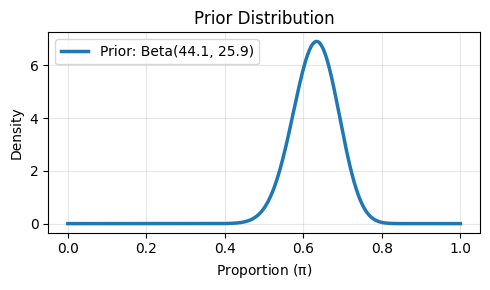

In [7]:
from scipy.stats import beta

x = np.linspace(0, 1, 500)

y_informative = beta.pdf(x, 44.1, 25.9)

plt.figure(figsize=(5, 3))

plt.plot(x, y_informative, label='Prior: Beta(44.1, 25.9)', color='#1f77b4', lw=2.5)

plt.title('Prior Distribution')
plt.xlabel('Proportion ($\pi$)')
plt.ylabel('Density')

plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Posterior Distribution

Since our priors are of the form $\pi \sim \operatorname{Beta}(\alpha,\beta)$ and the data follows a Binomial distribution $Y \sim \operatorname{Binomial}(n,\pi)$, we can obtain the posterior distributions analytically. This is done by adding the number of successes ($Y$) to $\alpha$ and the number of failures ($n - Y$) to $\beta$:

$$
\pi \mid Y \sim \operatorname{Beta}(\alpha + Y, \beta + n - Y)
$$

In our case, we use the previously defined informative prior $\operatorname{Beta}(44.1, 25.9)$. Based on the dataset:

- **Case M (Mirotic on court):**
    - $n_M = 2132$, $Y_M = 1417$
    - **Posterior:** $\operatorname{Beta}(44.1 + Y_M, 25.9 + n_M - Y_M)$

- **Case N (Mirotic off court):**
    - $n_N = 1510$, $Y_N = 910$
    - **Posterior:** $\operatorname{Beta}(44.1 + Y_N, 25.9 + n_N - Y_N)$

In the next cell, we visualize how the team's global prior is updated with the specific data from each case.

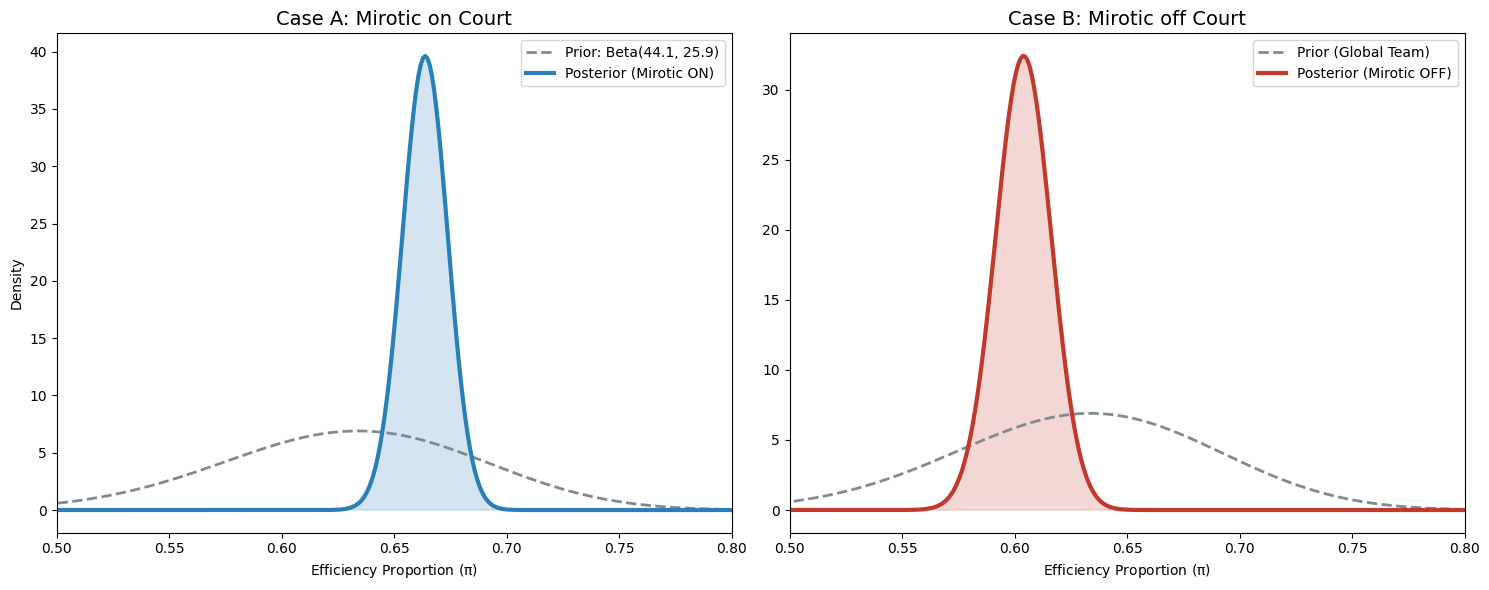

In [8]:
from scipy.stats import beta

# Case M: Mirotic on court
n_M = len(df_mirotic)
Y_M = df_mirotic['good_shot'].sum()

# Case N: No Mirotic on court
n_N = len(df_no_mirotic)
Y_N = df_no_mirotic['good_shot'].sum()

# Prior definition
alpha_prior, beta_prior = 44.1, 25.9

# Posterior calculation
alpha_post_M, beta_post_M = alpha_prior + Y_M, beta_prior + (n_M - Y_M)
alpha_post_N, beta_post_N = alpha_prior + Y_N, beta_prior + (n_N - Y_N)

# --- VISUALIZATION ---
x = np.linspace(0, 1, 1000)
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

c_prior = '#7f8c8d'
c_post_M = '#2980b9'
c_post_N = '#c0392b'

# SUBGRAPH 1: CASE M (Mirotic)
axs[0].plot(x, beta.pdf(x, alpha_prior, beta_prior), color=c_prior, lw=2, ls='--', label=f'Prior: Beta({alpha_prior}, {beta_prior})')
axs[0].plot(x, beta.pdf(x, alpha_post_M, beta_post_M), color=c_post_M, lw=3, label='Posterior (Mirotic ON)')
axs[0].fill_between(x, beta.pdf(x, alpha_post_M, beta_post_M), alpha=0.2, color=c_post_M)
axs[0].set_title('Case A: Mirotic on Court', fontsize=14)
axs[0].set_xlabel('Efficiency Proportion ($\pi$)')
axs[0].set_ylabel('Density')
axs[0].legend()

# SUBGRAPH 2: CASE N (No Mirotic)
axs[1].plot(x, beta.pdf(x, alpha_prior, beta_prior), color=c_prior, lw=2, ls='--', label='Prior (Global Team)')
axs[1].plot(x, beta.pdf(x, alpha_post_N, beta_post_N), color=c_post_N, lw=3, label='Posterior (Mirotic OFF)')
axs[1].fill_between(x, beta.pdf(x, alpha_post_N, beta_post_N), alpha=0.2, color=c_post_N)
axs[1].set_title('Case B: Mirotic off Court', fontsize=14)
axs[1].set_xlabel('Efficiency Proportion ($\pi$)')
axs[1].legend()

# Ajustar límites para ver mejor las campanas (alrededor del 63%)
plt.xlim(0.5, 0.8) 
plt.tight_layout()
plt.show()

In the result of the next cell, we can see the **posterior mean**, the **posterior standard deviation** and the **middle 95% posterior creadible interval** for each case:

In [9]:
from scipy.stats import beta

posteriors = {
    'Case M (Mirotic ON)': (alpha_post_M, beta_post_M),
    'Case N (Mirotic OFF)': (alpha_post_N, beta_post_N)
}

results = []
for name, (a, b) in posteriors.items():
    # Mean and variance calculation
    mean, var = beta.stats(a, b, moments='mv')
    # STD calculation
    std = var**0.5
    
    # 95% Credible Interval
    ci_lower = beta.ppf(0.025, a, b) 
    ci_upper = beta.ppf(0.975, a, b) 
    
    results.append({
        'Model Context': name,
        'Posterior Mean': f"{mean:.4f}",
        'Std Dev': f"{std:.4f}",
        '95% Credible Interval': f"[{ci_lower:.4f}, {ci_upper:.4f}]"
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

       Model Context Posterior Mean Std Dev 95% Credible Interval
 Case M (Mirotic ON)         0.6635  0.0101      [0.6437, 0.6831]
Case N (Mirotic OFF)         0.6039  0.0123      [0.5796, 0.6278]


We can see that we have around a 6% more chance to end the play with a good shot if we have Mirotic on the court. Moreover, we can see that there is no intersection between the credible intervals, so we can be highly confident that the team is better when Mirotic is playing.

## 5. Numerical Probability

To determine the probability that the team is more efficient with Mirotic on court, we perform a Monte Carlo simulation. We draw 100,000 random samples from both posterior distributions:
- $\pi_M \sim \operatorname{Beta}(44.1 + Y_M, 25.9 + n_M - Y_M)$
- $\pi_N \sim \operatorname{Beta}(44.1 + Y_N, 25.9 + n_N - Y_N)$

Then, we calculate the proportion of samples where $\pi_M > \pi_N$.

Probability of Mirotic improving the performance of the team: 99.9950%


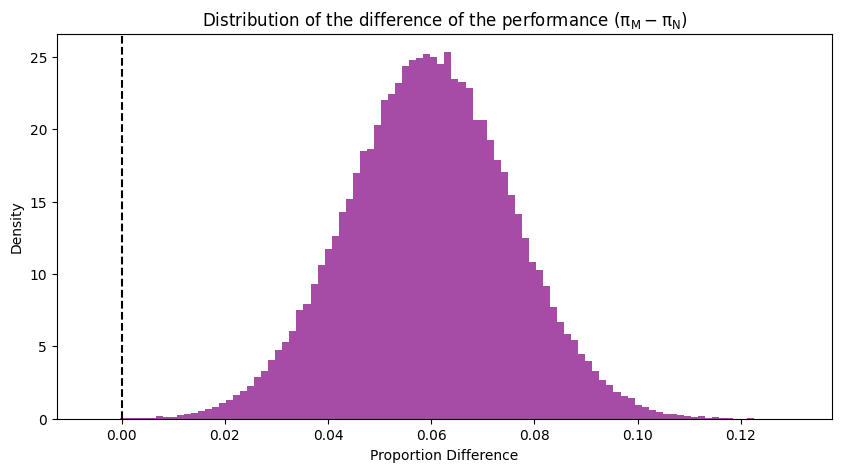

In [10]:
# Number of simulations
n_sims = 100000

# We generate samples from the posterior distributions
samples_M = np.random.beta(alpha_post_M, beta_post_M, n_sims)
samples_N = np.random.beta(alpha_post_N, beta_post_N, n_sims)

# We calculate the probability that having Mirotic on the court improves the efficiency compared to not having him
prob_M_better = np.mean(samples_M > samples_N)

print(f"Probability of Mirotic improving the performance of the team: {prob_M_better:.4%}")

plt.figure(figsize=(10, 5))
plt.hist(samples_M - samples_N, bins=100, color='purple', alpha=0.7, density=True)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of the difference of the performance ($\pi_M - \pi_N$)')
plt.xlabel('Proportion Difference')
plt.ylabel('Density')
plt.show()

According to this Monte-Carlo simulation, we can be 99.995% sure that when we have Mirotic on court, we have more probability of taking a good shot at the end of a play.